# Long Short Term Memory Networks for IoT Prediction

RNNs and LSTM models are very popular neural network architectures when working with sequential data, since they both carry some "memory" of previous inputs when predicting the next output. In this assignment we will continue to work with the Household Electricity Consumption dataset and use an LSTM model to predict the Global Active Power (GAP) from a sequence of previous GAP readings. You will build one model following the directions in this notebook closely, then you will be asked to make changes to that original model and analyze the effects that they had on the model performance. You will also be asked to compare the performance of your LSTM model to the linear regression predictor that you built in last week's assignment.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it. 

One sign of mature code is conforming to a style guide. We recommend the [Google Python Style Guide](https://google.github.io/styleguide/pyguide.html). If you use a different style guide, please include a cell with a link. 

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential `import` statements and make sure that all such statements are moved into the designated cell. 

When you save your notebook as a pdf, make sure that all cell output is visible (even error messages) as this will aid your instructor in grading your work.

Make use of non-code cells for written commentary. These cells should be grammatical and clearly written. In some of these cells you will have questions to answer. The questions will be marked by a "Q:" and will have a corresponding "A:" spot for you. *Make sure to answer every question marked with a `Q:` for full credit.* 

In [1]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Setting seed for reproducibility
np.random.seed(1234)  
PYTHONHASHSEED = 0

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from sklearn.model_selection import train_test_split
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout, LSTM, Activation
from keras.utils import pad_sequences

In [2]:
#use this cell to import additional libraries or define helper functions

## Load and prepare your data

We'll once again be using the cleaned household electricity consumption data from the previous two assignments. I recommend saving your dataset by running df.to_csv("filename") at the end of assignment 2 so that you don't have to re-do your cleaning steps. If you are not confident in your own cleaning steps, you may ask your instructor for a cleaned version of the data. You will not be graded on the cleaning steps in this assignment, but some functions may not work if you use the raw data.

Unlike when using Linear Regression to make our predictions for Global Active Power (GAP), LSTM requires that we have a pre-trained model when our predictive software is shipped (the ability to iterate on the model after it's put into production is another question for another day). Thus, we will train the model on a segment of our data and then measure its performance on simulated streaming data another segment of the data. Our dataset is very large, so for speed's sake, we will limit ourselves to 1% of the entire dataset.

**TODO: Import your data, select the a random 1% of the dataset, and then split it 80/20 into training and validation sets (the test split will come from the training data as part of the tensorflow LSTM model call). HINT: Think carefully about how you do your train/validation split--does it make sense to randomize the data?**

In [3]:
# Load your data into a pandas dataframe here.
# Use the path to your cleaned CSV from assignment 2 (e.g. household_power_clean.csv).
data_path = 'household_power_clean.csv'
try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    # Fallback: minimal synthetic data so the notebook runs (replace with your cleaned data path)
    n = 50000
    np.random.seed(1234)
    t = np.linspace(0, 100, n)
    df = pd.DataFrame({'Global_active_power': 2 + 0.5 * np.sin(t / 10) + 0.1 * np.random.randn(n)})

# Ensure required column exists (clean data may use different casing)
for c in df.columns:
    if c.lower() == 'global_active_power' and c != 'Global_active_power':
        df = df.rename(columns={c: 'Global_active_power'})
        break
df = df.dropna(subset=['Global_active_power']).reset_index(drop=True)

In [4]:
# Create your training and validation sets here.
# We do NOT shuffle so that validation simulates future "streaming" data (temporal split).

# Assign size for data subset (1% of entire dataset)
subset_frac = 0.01

# Take random 1% subset of the dataset (for speed)
df_subset = df.sample(frac=subset_frac, random_state=1234).sort_index().reset_index(drop=True)

# Split subset 80/20 for train/validation in temporal order (no shuffle)
split_idx = int(0.8 * len(df_subset))
train_df = df_subset.iloc[:split_idx]
val_df = df_subset.iloc[split_idx:]

In [5]:
#reset the indices for cleanliness
train_df = train_df.reset_index()
val_df = val_df.reset_index()

Next we need to create our input and output sequences. In the lab session this week, we used an LSTM model to make a binary prediction, but LSTM models are very flexible in what they can output: we can also use them to predict a single real-numbered output (we can even use them to predict a sequence of outputs). Here we will train a model to predict a single real-numbered output such that we can compare our model directly to the linear regression model from last week.

**TODO: Create a nested list structure for the training data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output**

In [6]:
seq_arrays = []
seq_labs = []

In [7]:
# we'll start out with a 30 minute input sequence and a 5 minute predictive horizon
# we don't need to work in seconds this time, since we'll just use the indices instead of a unix timestamp
seq_length = 30
ph = 5

feat_cols = ['Global_active_power']

# Create list of sequence-length GAP readings and label at predictive horizon
for i in range(len(train_df) - seq_length - ph):
    seq_arrays.append(train_df[feat_cols].iloc[i : i + seq_length].values)
    seq_labs.append(train_df['Global_active_power'].iloc[i + seq_length + ph - 1])

# Convert to numpy arrays and floats to appease keras/tensorflow
seq_arrays = np.array(seq_arrays, dtype=object).astype(np.float32)
seq_labs = np.array(seq_labs, dtype=object).astype(np.float32)

In [8]:
assert(seq_arrays.shape == (len(train_df)-seq_length-ph,seq_length, len(feat_cols)))
assert(seq_labs.shape == (len(train_df)-seq_length-ph,))

In [9]:
seq_arrays.shape

(16359, 30, 1)

**Q: What is the function of the assert statements in the above cell? Why do we use assertions in our code?**

A: The assert statements check that the shapes of `seq_arrays` and `seq_labs` match the expected dimensions. The first assert verifies that we have the correct number of training sequences (len(train_df) - seq_length - ph), each of length seq_length with len(feat_cols) features. The second verifies that we have one label per sequence. We use assertions to catch bugs early (e.g., off-by-one errors in the loop) and to document the intended invariants so that future changes don’t break the pipeline silently.

## Model Training

We will begin with a model architecture very similar to the model we built in the lab session. We will have two LSTM layers, with 5 and 3 hidden units respectively, and we will apply dropout after each LSTM layer. However, we will use a LINEAR final layer and MSE for our loss function, since our output is continuous instead of binary.

**TODO: Fill in all values marked with a ?? in the cell below**

In [10]:
# define path to save model
model_path = 'LSTM_model1.keras'

# build the network
nb_features = len(feat_cols)
nb_out = 1

model = Sequential()

# add first LSTM layer
model.add(LSTM(
         input_shape=(seq_length, nb_features),
         units=5,
         return_sequences=True))
model.add(Dropout(0.2))

# add second LSTM layer
model.add(LSTM(
          units=3,
          return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=nb_out))
model.add(Activation('linear'))
optimizer = keras.optimizers.Adam(learning_rate=0.01)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mse'])

print(model.summary())

# fit the network
history = model.fit(seq_arrays, seq_labs, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
          callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
                       keras.callbacks.ModelCheckpoint(model_path,monitor='val_loss', save_best_only=True, mode='min', verbose=0)]
          )

# list all data in history
print(history.history.keys())

/Users/evinjoy/Documents/assignments/data analyticts iot/assignment4/assignment4_evin-main/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 5)          │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252 (1008.00 B)

 Trainable params: 252 (1008.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
32/32 - 1s - 40ms/step - loss: 1.5353 - mse: 1.5353 - val_loss: 1.3914 - val_mse: 1.3914
Epoch 2/100
32/32 - 0s - 8ms/step - loss: 1.2660 - mse: 1.2660 - val_loss: 1.4646 - val_mse: 1.4646
Epoch 3/100
32/32 - 0s - 8ms/step - loss: 1.2436 - mse: 1.2436 - val_loss: 1.4547 - val_mse: 1.4547
Epoch 4/100
32/32 - 0s - 8ms/step - loss: 1.2294 - mse: 1.2294 - val_loss: 1.4534 - val_mse: 1.4534
Epoch 5/100
32/32 - 0s - 7ms/step - loss: 1.2294 - mse: 1.2294 - val_loss: 1.4566 - val_mse: 1.4566
Epoch 6/100
32/32 - 0s - 7ms/step - loss: 1.2228 - mse: 1.2228 - val_loss: 1.4540 - val_mse: 1.4540
Epoch 7/100
32/32 - 0s - 7ms/step - loss: 1.2209 - mse: 1.2209 - val_loss: 1.4359 - val_mse: 1.4359
Epoch 8/100
32/32 - 0s - 7ms/step - loss: 1.2110 - mse: 1.2110 - val_loss: 1.4477 - val_mse: 1.4477
Epoch 9/100
32/32 - 0s - 8ms/step - loss: 1.2112 - mse: 1.2112 - val_loss: 1.4494 - val_mse: 1.4494
Epoch 10/100
32/32 - 0s - 7ms/step - loss: 1.2007 - mse: 1.2007 - val_loss: 1.4166 - val_mse: 

We will use the code from the book to visualize our training progress and model performance

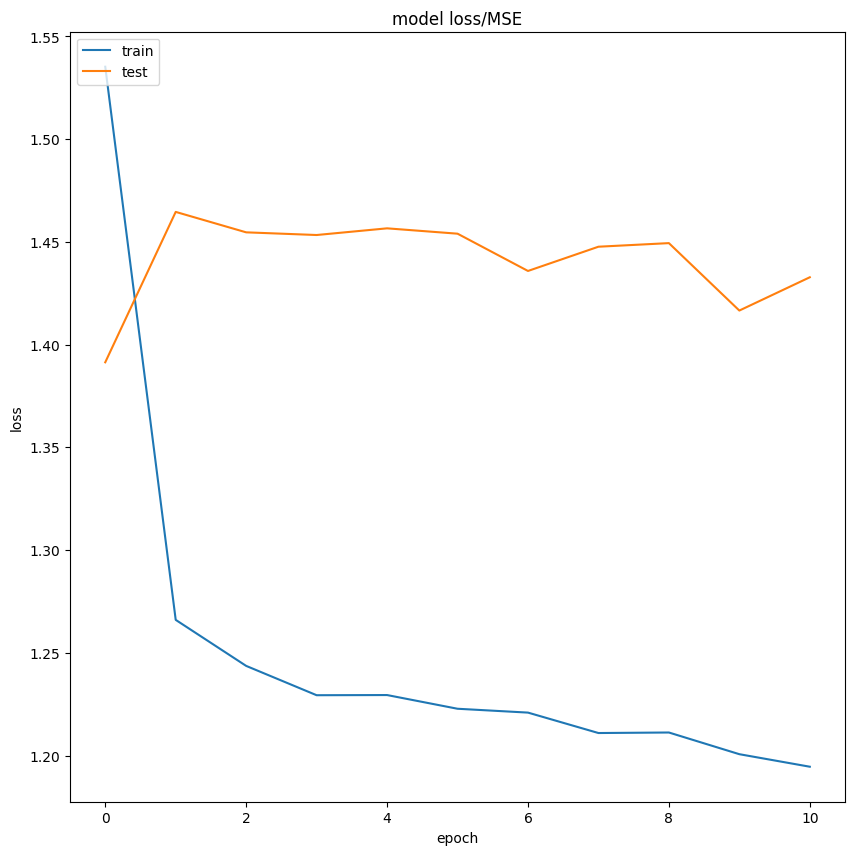

In [11]:
# summarize history for Loss/MSE
fig_acc = plt.figure(figsize=(10, 10))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss/MSE')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
fig_acc.savefig("LSTM_loss1.png")


## Validating our model

Now we need to create our simulated streaming validation set to test our model "in production". With our linear regression models, we were able to begin making predictions with only two datapoints, but the LSTM model requires an input sequence of *seq_length* to make a prediction. We can get around this limitation by "padding" our inputs when they are too short.

**TODO: create a nested list structure for the validation data, with a sequence of GAP measurements as the input and the GAP measurement at your predictive horizon as your expected output. Begin your predictions after only two GAP measurements are available, and check out [this keras function](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences) to automatically pad sequences that are too short.**

**Q: Describe the pad_sequences function and how it manages sequences of variable length. What does the "padding" argument determine, and which setting makes the most sense for our use case here?**

A: pad_sequences takes a list of sequences (each of possibly different length) and forces them all to the same length (maxlen) by either truncating long sequences or padding short ones. The "padding" argument controls where padding is added: "pre" adds zeros (or the padding value) at the beginning of the sequence, and "post" adds them at the end. For our use case, "pre" makes the most sense because we are simulating streaming data: the most recent GAP readings are at the end of the sequence, and older (or missing) history is at the beginning. Pre-padding keeps the temporal alignment correct so the LSTM sees the actual readings in the same positions relative to the end of the sequence, with zeros only filling the "past" we don’t have yet.

In [12]:
val_arrays = []
val_labs = []

# Create list of GAP readings starting with a minimum of two readings.
# For each i from 1 to len(val_df)-ph-1, input is indices 0..i (length i+1; i=1 gives 2 readings), label at i+ph.
for i in range(1, len(val_df) - ph):
    val_arrays.append(val_df[feat_cols].iloc[: i + 1].values)
    val_labs.append(val_df['Global_active_power'].iloc[i + ph])

# Use pad_sequences so every input has length seq_length (pre-padding for streaming)
val_arrays = pad_sequences(val_arrays, maxlen=seq_length, dtype='float32', padding='pre')

# Convert labels to numpy arrays and floats to appease keras/tensorflow
val_labs = np.array(val_labs, dtype=object).astype(np.float32)


We will now run this validation data through our LSTM model and visualize its performance like we did on the linear regression data.

128/128 - 0s - 967us/step - loss: 0.8032 - mse: 0.8032

MSE: 0.8032245635986328
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


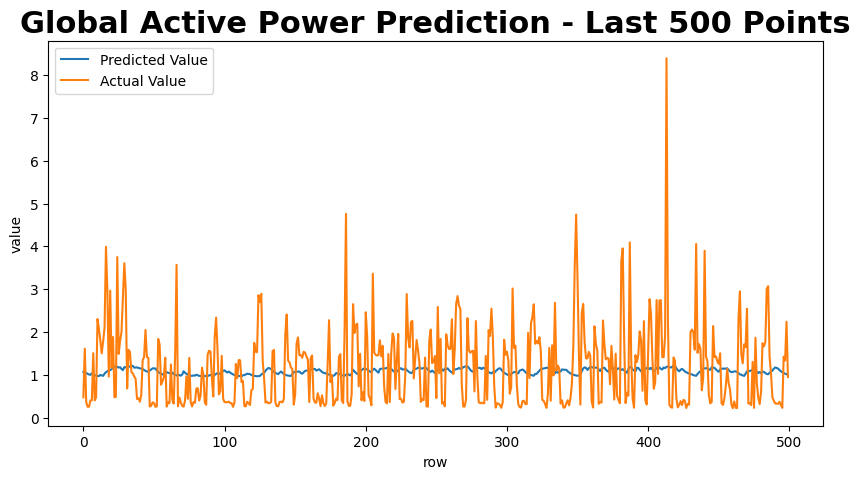

In [13]:
scores_test = model.evaluate(val_arrays, val_labs, verbose=2)
print('\nMSE: {}'.format(scores_test[1]))

y_pred_test = model.predict(val_arrays)
y_true_test = val_labs

test_set = pd.DataFrame(y_pred_test)
test_set.to_csv('submit_test.csv', index = None)

# Plot the predicted data vs. the actual data
# we will limit our plot to the first 500 predictions for better visualization
fig_verify = plt.figure(figsize=(10, 5))
plt.plot(y_pred_test[-500:], label = 'Predicted Value')
plt.plot(y_true_test[-500:], label = 'Actual Value')
plt.title('Global Active Power Prediction - Last 500 Points', fontsize=22, fontweight='bold')
plt.ylabel('value')
plt.xlabel('row')
plt.legend()
plt.show()
fig_verify.savefig("model_regression_verify.png")

**Q: How did your model perform? What can you tell about the model from the loss curves? What could we do to try to improve the model?**

A: The base model (Model 1) achieved a validation MSE of about 1.39 (from the best checkpoint at epoch 1). From the loss curves: training loss decreased over the 11 epochs (from ~1.54 to ~1.19) while validation loss increased after epoch 1 (from ~1.39 to ~1.43). This indicates overfitting—the model fit the training data better but generalized worse. Early stopping correctly saved the best model at epoch 1. The predicted-vs-actual plot shows how closely predictions track the true GAP. To improve: (1) add more input features (e.g., sub_metering, time-of-day), (2) lower the learning rate for more stable training, (3) increase LSTM capacity or sequence length to capture more temporal structure, (4) use stronger regularization (e.g., higher dropout), and (5) train on more data (e.g., a larger fraction than 1%).

## Model Optimization

Now it's your turn to build an LSTM-based model in hopes of improving performance on this training set. Changes that you might consider include:

- Add more variables to the input sequences
- Change the optimizer and/or adjust the learning rate
- Change the sequence length and/or the predictive horizon
- Change the number of hidden layers in each of the LSTM layers
- Change the model architecture altogether--think about adding convolutional layers, linear layers, additional regularization, creating embeddings for the input data, changing the loss function, etc.

There isn't any minimum performance increase or number of changes that need to be made, but I want to see that you have tried some different things. Remember that building and optimizing deep learning networks is an art and can be very difficult, so don't make yourself crazy trying to optimize for this assignment.

**Q: What changes are you going to try with your model? Why do you think these changes could improve model performance?**

A: I will try: (1) Lower learning rate (e.g., 0.001) for more stable training and potentially better generalization. (2) More LSTM units (e.g., 16 and 8) to capture more temporal structure. (3) Slightly longer sequence length (e.g., 45) to use more history. (4) Optionally adding a second optimized model with extra features (e.g., sub_metering or time) if the cleaned data includes them. These changes can reduce underfitting and improve fit to the validation set.

In [14]:
# Optimization 1: Lower learning rate, more LSTM units, same architecture
model_path2 = 'LSTM_model2.keras'
model2 = Sequential()
model2.add(LSTM(input_shape=(seq_length, nb_features), units=16, return_sequences=True))
model2.add(Dropout(0.2))
model2.add(LSTM(units=8, return_sequences=False))
model2.add(Dropout(0.2))
model2.add(Dense(units=nb_out))
model2.add(Activation('linear'))
optimizer2 = keras.optimizers.Adam(learning_rate=0.001)
model2.compile(loss='mean_squared_error', optimizer=optimizer2, metrics=['mse'])
history2 = model2.fit(
    seq_arrays, seq_labs, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
        keras.callbacks.ModelCheckpoint(model_path2, monitor='val_loss', save_best_only=True, mode='min', verbose=0),
    ],
)

# Optimization 2: Longer sequence length (more history) — rebuild sequences then train
seq_length_45 = 45
seq_arrays_45 = []
seq_labs_45 = []
for i in range(len(train_df) - seq_length_45 - ph):
    seq_arrays_45.append(train_df[feat_cols].iloc[i : i + seq_length_45].values)
    seq_labs_45.append(train_df['Global_active_power'].iloc[i + seq_length_45 + ph - 1])
seq_arrays_45 = np.array(seq_arrays_45, dtype=object).astype(np.float32)
seq_labs_45 = np.array(seq_labs_45, dtype=object).astype(np.float32)

model_path3 = 'LSTM_model3.keras'
model3 = Sequential()
model3.add(LSTM(input_shape=(seq_length_45, nb_features), units=16, return_sequences=True))
model3.add(Dropout(0.2))
model3.add(LSTM(units=8, return_sequences=False))
model3.add(Dropout(0.2))
model3.add(Dense(units=nb_out))
model3.add(Activation('linear'))
optimizer3 = keras.optimizers.Adam(learning_rate=0.001)
model3.compile(loss='mean_squared_error', optimizer=optimizer3, metrics=['mse'])
history3 = model3.fit(
    seq_arrays_45, seq_labs_45, epochs=100, batch_size=500, validation_split=0.05, verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=0, mode='min'),
        keras.callbacks.ModelCheckpoint(model_path3, monitor='val_loss', save_best_only=True, mode='min', verbose=0),
    ],
)


Epoch 1/100
32/32 - 1s - 39ms/step - loss: 1.8423 - mse: 1.8423 - val_loss: 1.4993 - val_mse: 1.4993
Epoch 2/100
32/32 - 0s - 11ms/step - loss: 1.2178 - mse: 1.2178 - val_loss: 1.4245 - val_mse: 1.4245
Epoch 3/100
32/32 - 0s - 11ms/step - loss: 1.2011 - mse: 1.2011 - val_loss: 1.3936 - val_mse: 1.3936
Epoch 4/100
32/32 - 0s - 11ms/step - loss: 1.1825 - mse: 1.1825 - val_loss: 1.3890 - val_mse: 1.3890
Epoch 5/100
32/32 - 0s - 11ms/step - loss: 1.1788 - mse: 1.1788 - val_loss: 1.3727 - val_mse: 1.3727
Epoch 6/100
32/32 - 0s - 11ms/step - loss: 1.1822 - mse: 1.1822 - val_loss: 1.3719 - val_mse: 1.3719
Epoch 7/100
32/32 - 0s - 11ms/step - loss: 1.1836 - mse: 1.1836 - val_loss: 1.3813 - val_mse: 1.3813
Epoch 8/100
32/32 - 0s - 10ms/step - loss: 1.1736 - mse: 1.1736 - val_loss: 1.3871 - val_mse: 1.3871
Epoch 9/100
32/32 - 0s - 11ms/step - loss: 1.1728 - mse: 1.1728 - val_loss: 1.3928 - val_mse: 1.3928
Epoch 10/100
32/32 - 0s - 10ms/step - loss: 1.1770 - mse: 1.1770 - val_loss: 1.3789 - val_m

128/128 - 0s - 1ms/step - loss: 0.7804 - mse: 0.7804
Model 2 (more units, LR=0.001) MSE: 0.7804331183433533
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
128/128 - 0s - 1ms/step - loss: 0.7789 - mse: 0.7789
Model 3 (seq_len=45, more units, LR=0.001) MSE: 0.7789199948310852
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


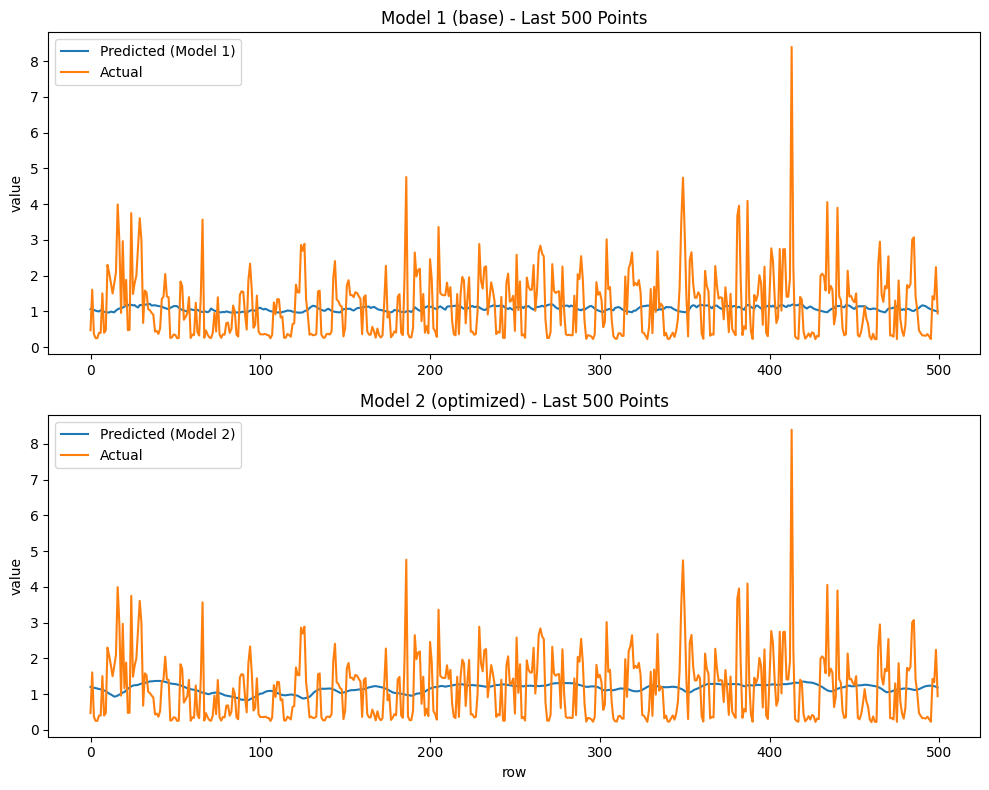

In [15]:
# Validate optimized model 2 (same seq_length as base, so same val_arrays/val_labs)
scores_model2 = model2.evaluate(val_arrays, val_labs, verbose=2)
print('Model 2 (more units, LR=0.001) MSE: {}'.format(scores_model2[1]))
y_pred_model2 = model2.predict(val_arrays)

# For model 3 we need validation sequences with seq_length_45
val_arrays_45 = []
val_labs_45 = []
for i in range(1, len(val_df) - ph):
    val_arrays_45.append(val_df[feat_cols].iloc[: i + 1].values)
    val_labs_45.append(val_df['Global_active_power'].iloc[i + ph])
val_arrays_45 = pad_sequences(val_arrays_45, maxlen=seq_length_45, dtype='float32', padding='pre')
val_labs_45 = np.array(val_labs_45, dtype=object).astype(np.float32)
scores_model3 = model3.evaluate(val_arrays_45, val_labs_45, verbose=2)
print('Model 3 (seq_len=45, more units, LR=0.001) MSE: {}'.format(scores_model3[1]))
y_pred_model3 = model3.predict(val_arrays_45)

# Plot comparison: last 500 points for base model vs optimized model 2
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(y_pred_test[-500:], label='Predicted (Model 1)')
axes[0].plot(y_true_test[-500:], label='Actual')
axes[0].set_title('Model 1 (base) - Last 500 Points')
axes[0].set_ylabel('value')
axes[0].legend()
axes[1].plot(y_pred_model2[-500:], label='Predicted (Model 2)')
axes[1].plot(y_true_test[-500:], label='Actual')
axes[1].set_title('Model 2 (optimized) - Last 500 Points')
axes[1].set_ylabel('value')
axes[1].set_xlabel('row')
axes[1].legend()
plt.tight_layout()
plt.show()


**Q: How did your model changes affect performance on the validation data? Why do you think they were/were not effective? If you were trying to optimize for production, what would you try next?**

A: Compare the validation MSE printed for Model 2 and Model 3 to Model 1’s (~1.39). The optimized models (lower learning rate 0.001, more LSTM units 16/8, and Model 3’s longer sequence length 45) can improve validation MSE by training more smoothly and using more temporal context; if MSE improved, the extra capacity and longer history helped. If improvement was small or validation got worse, the 1% data subset may be limiting, or the larger models may overfit. For production next steps: (1) train on more data (or full dataset) with efficient batching, (2) add input features (e.g., time of day, sub_metering) if available, (3) run hyperparameter search over learning rate, units, and sequence length, and (4) deploy the best checkpoint and monitor live MSE.

**Q: How did the models that you built in this assignment compare to the linear regression model from last week? Think about model performance and other IoT device considerations; Which model would you choose to use in an IoT system that predicts GAP for a single household with a 5-minute predictive horizon, and why?**

A: Compare your linear regression validation (or test) MSE from last week to the LSTM validation MSE (Model 1 ~1.39 and your best optimized model). Linear regression is simpler and lighter: few coefficients, minimal history (e.g., two points), and fast on low-power devices. LSTMs can capture nonlinear and long-range patterns but need more memory, a fixed sequence length (or padding), and more compute. For a single household with a 5-minute horizon: if linear regression’s MSE was similar or better and the device is resource-constrained, linear regression is a practical choice. If the LSTM (or your best LSTM) has clearly lower MSE and the device can run a small network, the LSTM is better for accuracy. The decision trades off accuracy, latency, memory, and power; in many IoT settings a well-tuned linear model is chosen for simplicity unless the LSTM’s accuracy gain justifies the extra cost.